# Joint SFS
Given several populations, the {class}`~sfsutils.parser.Parser` counts derived alleles jointly rather than pooling them, yielding the joint SFS: an array whose entry $(i, j, \dots)$ is the number of sites with $i$ derived alleles in the first population, $j$ in the second, and so on. Populations are supplied as a mapping from name to sample names via `pops`, and `n` sets the sample size each population is projected to. Parsing then returns a {class}`~sfsutils.spectrum.JointSpectra`, holding one {class}`~sfsutils.spectrum.JointSFS` per type.

In [1]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [4.4, 3.3]

The example VCF for `Betula spp.` carries samples from several localities, encoded in the sample names. We take two of them as populations.

In [2]:
import sfsutils as su
from cyvcf2 import VCF

vcf = "resources/genome/betula/biallelic.polarized.subset.10000.vcf.gz"
samples = VCF(vcf).samples

pops = {loc: [s for s in samples if s.startswith(loc)] for loc in ["ASP", "PIT"]}

In [3]:
sfs = su.Parser(source=vcf, pops=pops, n=10).parse()

INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file
Parser>Counting sites: 10000it [00:00, 395461.48it/s]
Parser>Processing sites: 100%|██████████| 10000/10000 [00:01<00:00, 5957.09it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Skipped 345 sites without ancestral allele information.
INFO:Parser: Included 9496 out of 10000 sites in total from the VCF file.


For two populations the joint SFS is a matrix, plotted as a heatmap of derived-allele counts.

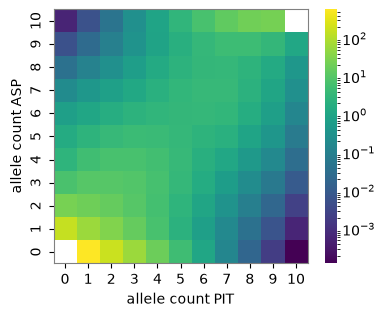

In [4]:
sfs["all"].plot();

Marginalizing over one population recovers the single-population SFS of the other, which lets the joint spectrum be reconciled with a one-dimensional parse.

In [5]:
sfs["all"].marginalize([0])  # the SFS of population ASP